# Perturbed Pixel

This notebook merges the VGG16 property results with per-image object ratios and writes a clean CSV for downstream L0 analysis.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "results" / "vggnet16" / "all_k_vggnet16.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate the XAIV project root from the current working directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
PLOT_DIR = PROJECT_ROOT / "plots" / "5.5.1_L0"
ALL_K_PATH = PROJECT_ROOT / "results" / "vggnet16" / "all_k_vggnet16.csv"
OBJECT_RATIO_PATH = PROJECT_ROOT / "results" / "vggnet16" / "imagenet_object_ratio_per_image.csv"
OUTPUT_PATH = PLOT_DIR / "imagenet_object_ratio_with_k_result_tag.csv"

all_k = pd.read_csv(ALL_K_PATH)
object_ratio = pd.read_csv(OBJECT_RATIO_PATH)

columns_to_keep = ["image", "tag", "result", "k", "total"]
merged = all_k[columns_to_keep].copy()
merged["k"] = pd.to_numeric(merged["k"], errors="coerce")
merged["total"] = pd.to_numeric(merged["total"], errors="coerce")
merged = merged.rename(columns={"tag": "raw_tag", "result": "raw_result"})

object_ratio["object_ratio"] = pd.to_numeric(object_ratio["object_ratio"], errors="coerce")
merged = merged.merge(object_ratio, on="image", how="left", validate="many_to_one")

if merged["object_ratio"].isna().any():
    missing_images = sorted(merged.loc[merged["object_ratio"].isna(), "image"].unique())
    raise ValueError(f"Missing object ratios for {len(missing_images)} images: {missing_images[:10]}")

merged["result"] = np.select(
    [
        merged["raw_result"].astype(str).str.startswith("unsat"),
        merged["raw_result"].astype(str).str.startswith("sat"),
    ],
    ["safe", "unsafe"],
    default="unknown",
)
merged["tag"] = merged["raw_tag"].map(
    {
        "global": "whole-image",
        "fix_nonmask": "object",
        "fix_mask": "background",
    }
)

if merged["tag"].isna().any():
    missing_tags = sorted(merged.loc[merged["tag"].isna(), "raw_tag"].dropna().unique())
    raise ValueError(f"Unexpected raw tags: {missing_tags}")

# `k` is a spatial-pixel budget. The original `total` column counts RGB channels.
merged["background_ratio"] = 1.0 - merged["object_ratio"]
merged["k_x_object_ratio"] = merged["k"] * merged["object_ratio"]
merged["k_x_background_ratio"] = merged["k"] * merged["background_ratio"]
merged["estimated_perturbed_pixel_by_tag"] = np.select(
    [
        merged["raw_tag"].eq("fix_nonmask"),
        merged["raw_tag"].eq("fix_mask"),
        merged["raw_tag"].eq("global"),
    ],
    [
        merged["k_x_object_ratio"],
        merged["k_x_background_ratio"],
        merged["k"],
    ],
    default=np.nan,
)
merged["total_pixel"] = merged["total"] / 3.0
merged["perturbed_pixel"] = np.select(
    [
        merged["tag"].eq("object"),
        merged["tag"].eq("background"),
        merged["tag"].eq("whole-image"),
    ],
    [
        merged["k_x_object_ratio"],
        merged["k_x_background_ratio"],
        merged["k"],
    ],
    default=np.nan,
)
merged["pixel_perturbed_percentage"] = (
    100.0 * merged["perturbed_pixel"] / merged["total_pixel"]
).round(10)
merged = merged.rename(columns={"total": "total_channel"})

merged = merged[
    [
        "image",
        "tag",
        "result",
        "k",
        "object_ratio",
        "background_ratio",
        "k_x_object_ratio",
        "k_x_background_ratio",
        "perturbed_pixel",
        "pixel_perturbed_percentage",
        "total_pixel",
    ]
]

merged.to_csv(OUTPUT_PATH, index=False)

print(f"Saved: {OUTPUT_PATH}")
print(f"Rows: {len(merged)}")
merged.head()


Saved: /Users/zd3504phd/Desktop/XAIV/plots/5.5.1_L0/imagenet_object_ratio_with_k_result_tag.csv
Rows: 3258


,image,tag,result,k,object_ratio,background_ratio,k_x_object_ratio,k_x_background_ratio,perturbed_pixel,pixel_perturbed_percentage,total_pixel
0,n01443537_goldfish,whole-image,safe,1568.0,0.812998,0.187002,1274.78125,293.21875,1568.00000,3.125000,50176.0
1,n01443537_goldfish,background,safe,1568.0,0.812998,0.187002,1274.78125,293.21875,293.21875,0.584380,50176.0
2,n01443537_goldfish,object,safe,1568.0,0.812998,0.187002,1274.78125,293.21875,1274.78125,2.540620,50176.0
3,n01484850_great_white_shark,whole-image,unsafe,1568.0,0.902264,0.097736,1414.75000,153.25000,1568.00000,3.125000,50176.0
4,n01484850_great_white_shark,background,unsafe,1568.0,0.902264,0.097736,1414.75000,153.25000,153.25000,0.305425,50176.0


excess data in 'kern' subtable: 6 bytes


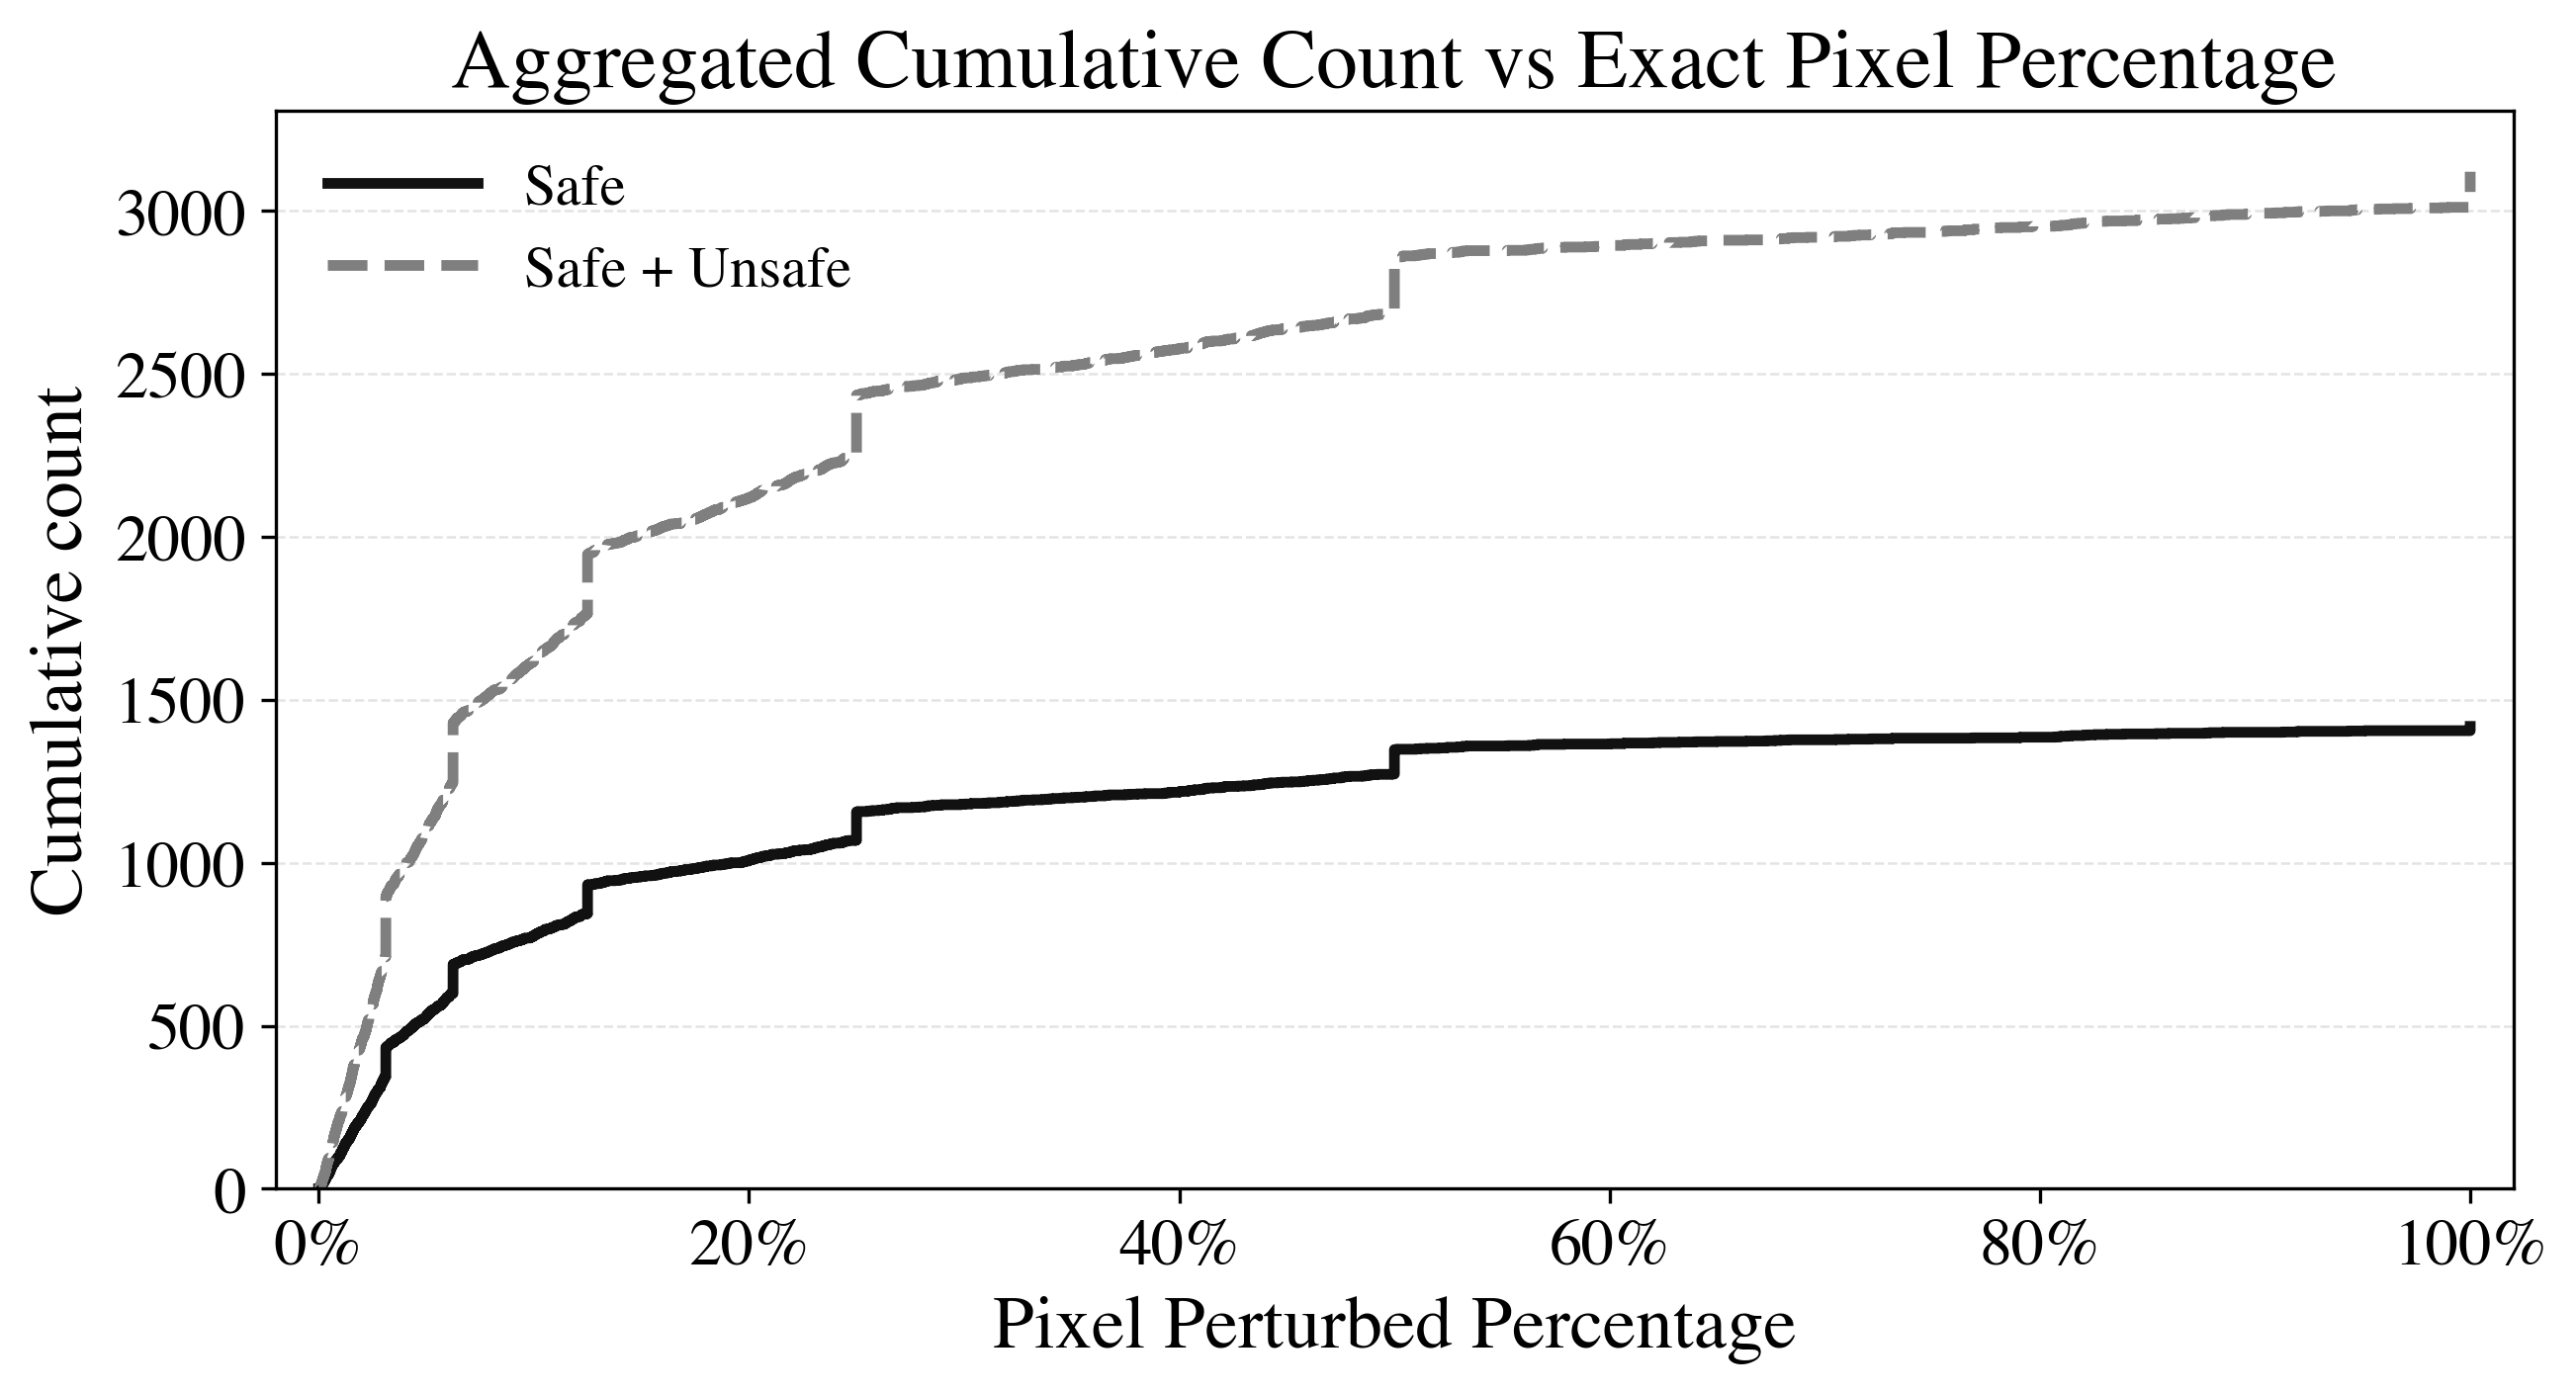

In [3]:
import matplotlib.pyplot as plt


STEP_ALL_PATH = PLOT_DIR / "imagenet_pixel_perturbed_percentage_step_all.csv"
STEP_SAFE_VS_ALL_PATH = PLOT_DIR / "imagenet_pixel_perturbed_percentage_step_safe_vs_all.csv"
PLOT_PDF_PATH = PLOT_DIR / "imagenet_pixel_perturbed_percentage_safe_vs_all.pdf"
PLOT_PNG_PATH = PLOT_DIR / "imagenet_pixel_perturbed_percentage_safe_vs_all.png"

step_all = (
    merged.assign(
        safe_count=(merged["result"] == "safe").astype(int),
        unsafe_count=(merged["result"] == "unsafe").astype(int),
        unknown_count=(merged["result"] == "unknown").astype(int),
    )
    .groupby("pixel_perturbed_percentage", as_index=False)
    .agg(
        safe_count=("safe_count", "sum"),
        unsafe_count=("unsafe_count", "sum"),
        unknown_count=("unknown_count", "sum"),
    )
    .sort_values("pixel_perturbed_percentage")
    .reset_index(drop=True)
)

step_all["safe_plus_unsafe_count"] = step_all["safe_count"] + step_all["unsafe_count"]
step_all["all_count"] = step_all["safe_plus_unsafe_count"] + step_all["unknown_count"]
step_all["safe_cumulative_count"] = step_all["safe_count"].cumsum()
step_all["unsafe_cumulative_count"] = step_all["unsafe_count"].cumsum()
step_all["unknown_cumulative_count"] = step_all["unknown_count"].cumsum()
step_all["safe_plus_unsafe_cumulative_count"] = step_all["safe_plus_unsafe_count"].cumsum()
step_all["all_cumulative_count"] = step_all["all_count"].cumsum()

step_safe_vs_all = step_all[
    [
        "pixel_perturbed_percentage",
        "safe_cumulative_count",
        "safe_plus_unsafe_cumulative_count",
    ]
].copy()

# step_all.to_csv(STEP_ALL_PATH, index=False)
# step_safe_vs_all.to_csv(STEP_SAFE_VS_ALL_PATH, index=False)

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

plot_x = np.concatenate(([0.0], step_safe_vs_all["pixel_perturbed_percentage"].to_numpy()))
plot_safe = np.concatenate(([0], step_safe_vs_all["safe_cumulative_count"].to_numpy()))
plot_safe_plus_unsafe = np.concatenate(
    ([0], step_safe_vs_all["safe_plus_unsafe_cumulative_count"].to_numpy())
)

fig, ax = plt.subplots(figsize=(8.8, 4.8), dpi=300)
ax.step(plot_x, plot_safe, where="post", color="#111111", linewidth=2.6, label="Safe")
ax.step(
    plot_x,
    plot_safe_plus_unsafe,
    where="post",
    color="#7F7F7F",
    linewidth=2.6,
    linestyle="--",
    label="Safe + Unsafe",
)

ax.set_title("Aggregated Cumulative Count vs Exact Pixel Percentage")
ax.set_xlabel("Pixel Perturbed Percentage")
ax.set_ylabel("Cumulative count")
ax.set_xlim(-2, 102)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])
ax.set_ylim(0, max(plot_safe_plus_unsafe) * 1.06)
ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
ax.legend(loc="upper left", frameon=False, handlelength=2.6)
ax.spines["top"].set_visible(True)
ax.spines["right"].set_visible(True)
fig.tight_layout()

fig.savefig(PLOT_PDF_PATH, bbox_inches="tight")
